<a href="https://colab.research.google.com/github/Zeldano118/QPon_NLP_PBA/blob/main/assignments/week%204/2_week4_tfidf_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 4: TF-IDF Sentiment Classification — QPon Reviews
Based on dosen's IMDB Colab, applied to QPon Google Play reviews.

**Input:** `df_qpon_rev.csv`

In [ ]:
!pip install xgboost -q
import pandas as pd
import numpy as np
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
stop_words = set(stopwords.words('indonesian'))

---
## Load Data

In [ ]:
from google.colab import files
uploaded = files.upload()

import io
for fn in uploaded.keys():
    df = pd.read_csv(io.BytesIO(uploaded[fn]))
    print(f'Loaded: {len(df):,} rows')
df.head()

Saving df_qpon_rev.csv to df_qpon_rev.csv
Loaded: 4,684 rows


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,85c1f968-1c50-4eb0-a84e-c4fdea4ac20d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tidak bisa login (alasan aktivitas mencurigaka...,1,170,2.21.0.1,2026-01-11 13:44:34,NaN,NaN,2.21.0.1
1,36aaf78f-66de-4b14-9adc-21575d7a94a3,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"aplikasi log out dengan sendirinya, pas login ...",1,79,2.21.0.1,2026-01-16 05:05:27,NaN,NaN,2.21.0.1
2,9a0b398e-d7b1-4679-a4d4-97f7aa47f9f6,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,kapok deh Awal doang enak . sekarang2 mau orde...,1,37,2.21.0.1,2026-01-11 04:31:11,NaN,NaN,2.21.0.1
3,113779d5-cae5-49f7-b67d-1a885af6f1fc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,CS gak bisa ngebantu buat login karena masalah...,1,52,2.24.0.1,2026-02-21 04:07:01,NaN,NaN,2.24.0.1
4,1d499b55-883c-422c-a83e-0a181330fd97,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,aplikasi banyak error. perkara ganti hape dibi...,1,2,2.24.0.1,2026-03-10 08:43:02,NaN,NaN,2.24.0.1


In [ ]:
df = df.dropna(subset=['content']).reset_index(drop=True)
df['sentiment'] = df['score'].apply(lambda x: 'positive' if x >= 4 else 'negative')
# drop neutral (score 3) for binary classification like IMDB
df = df[df['score'] != 3].reset_index(drop=True)
print(f'{len(df):,} reviews (binary: positive/negative)')
print(df['sentiment'].value_counts())

4,515 reviews (binary: positive/negative)
sentiment
negative    2328
positive    2187
Name: count, dtype: int64


---
## EDA

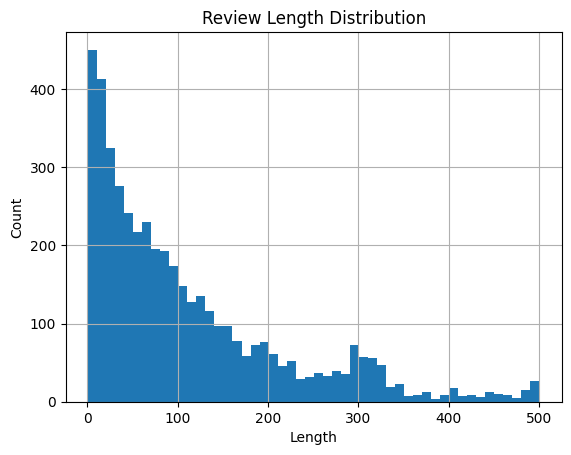

count    4515.000000
mean      110.438538
std       107.044072
min         1.000000
25%        29.000000
50%        76.000000
75%       156.000000
max       500.000000
dtype: float64


In [ ]:
# review length distribution
rev_len = [len(str(r)) for r in df['content']]
pd.Series(rev_len).hist(bins=50)
plt.title('Review Length Distribution')
plt.xlabel('Length')
plt.ylabel('Count')
plt.show()
print(pd.Series(rev_len).describe())

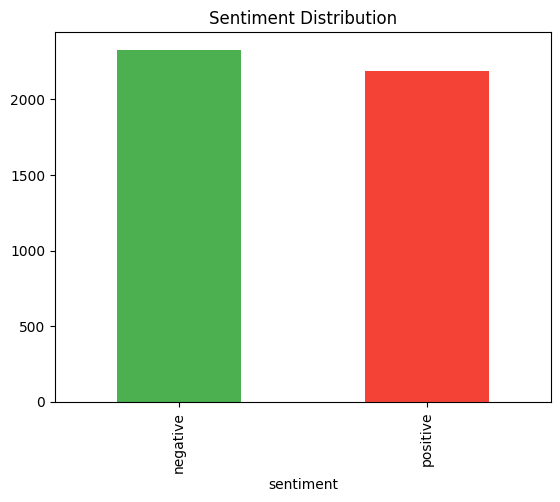

In [ ]:
# class distribution
df['sentiment'].value_counts().plot.bar(color=['#4CAF50', '#F44336'])
plt.title('Sentiment Distribution')
plt.show()

---
## Preprocessing

In [ ]:
def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = word_tokenize(text)
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return ' '.join(words)

df['clean'] = df['content'].apply(preprocess)
df['clean'].head()

,clean
0,login alasan aktivitas mencurigakan template s...
1,aplikasi log out pas login ulang gabisa alasan...
2,kapok deh doang enak sekarang2 order aja susah...
3,gak ngebantu login akun normal giliran tolong ...
4,aplikasi error perkara ganti hape dibilang gon...


---
## Train/Test Split

In [ ]:
x = df['clean']
le = LabelEncoder()
y = le.fit_transform(df['sentiment'])
print(f'Labels: {list(le.classes_)} → {list(range(len(le.classes_)))}')

xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)
print(f'Train: {len(xtrain):,}  Test: {len(xtest):,}')

Labels: ['negative', 'positive'] → [0, 1]
Train: 3,612  Test: 903


---
## TF-IDF Vectorization

In [ ]:
tfidf = TfidfVectorizer(max_features=5000)
xtrain_tfidf = tfidf.fit_transform(xtrain)
xtest_tfidf = tfidf.transform(xtest)
print(f'TF-IDF: {xtrain_tfidf.shape}')

TF-IDF: (3612, 5000)


---
## Classification

In [ ]:
def evaluate(name, model, xtest, ytest):
    pred = model.predict(xtest)
    acc = accuracy_score(ytest, pred)
    f1 = f1_score(ytest, pred, average='weighted')
    print(f'{name}: Accuracy={acc:.4f}, F1={f1:.4f}')
    return name, acc, f1, pred

In [ ]:
results = []

classifiers = [
    ('LinearSVM', LinearSVC()),
    ('LogisticRegression', LogisticRegression(max_iter=1000)),
    ('NaiveBayes', MultinomialNB()),
    ('XGBoost', XGBClassifier(eval_metric='logloss', verbosity=0)),
    ('RandomForest', RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)),
]

print('=== TF-IDF Classification Results ===\n')
preds = {}
for name, clf in classifiers:
    clf.fit(xtrain_tfidf, ytrain)
    n, acc, f1, pred = evaluate(name, clf, xtest_tfidf, ytest)
    results.append({'Model': n, 'Accuracy': acc, 'F1': f1})
    preds[n] = pred

=== TF-IDF Classification Results ===

LinearSVM: Accuracy=0.9158, F1=0.9158
LogisticRegression: Accuracy=0.8893, F1=0.8884
NaiveBayes: Accuracy=0.8937, F1=0.8930
XGBoost: Accuracy=0.8926, F1=0.8926
RandomForest: Accuracy=0.7508, F1=0.7324


In [ ]:
# results table
res_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
res_df

,Model,Accuracy,F1
0,LinearSVM,0.915836,0.915827
2,NaiveBayes,0.893688,0.892997
3,XGBoost,0.892580,0.892639
1,LogisticRegression,0.889258,0.888408
4,RandomForest,0.750831,0.732374


Best model: LinearSVM

              precision    recall  f1-score   support

    negative       0.92      0.92      0.92       473
    positive       0.91      0.91      0.91       430

    accuracy                           0.92       903
   macro avg       0.92      0.92      0.92       903
weighted avg       0.92      0.92      0.92       903



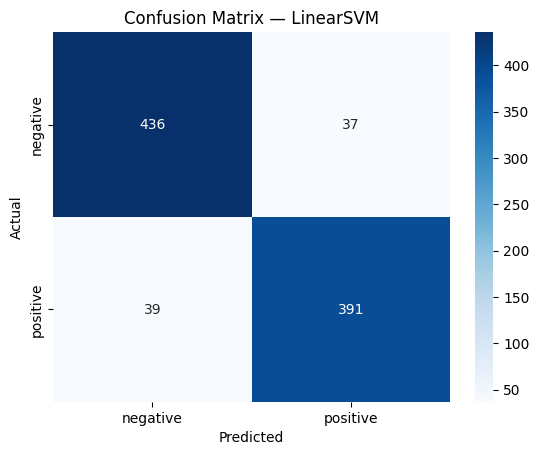

In [ ]:
# confusion matrix for best model
best = res_df.iloc[0]['Model']
print(f'Best model: {best}\n')
print(classification_report(ytest, preds[best], target_names=le.classes_))

cm = confusion_matrix(ytest, preds[best])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix — {best}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()